<a href="https://colab.research.google.com/github/bslht/openmplab/blob/main/matr2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

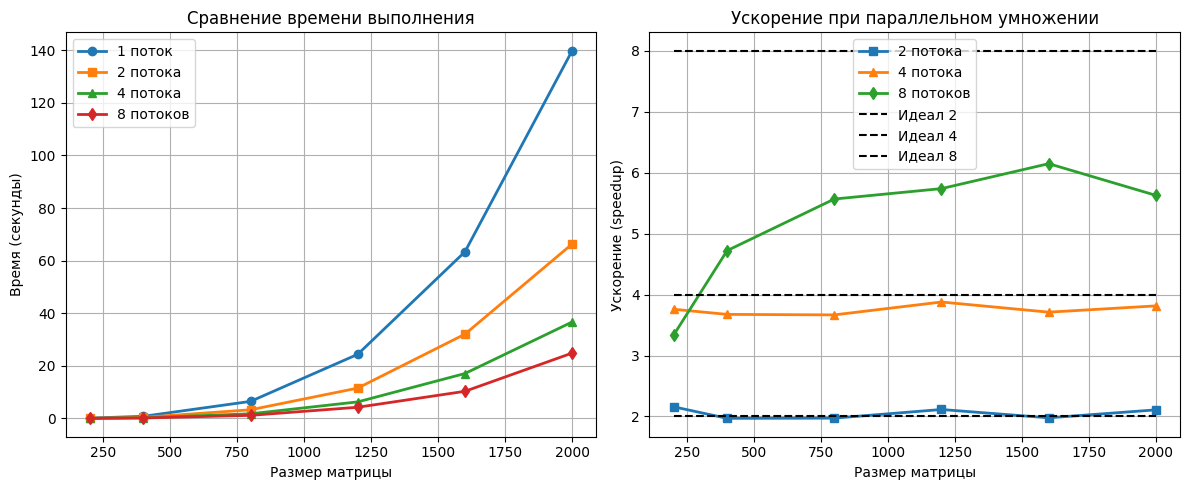

In [3]:
import matplotlib.pyplot as plt
import numpy as np

sizes = [200, 400, 800, 1200, 1600, 2000]
time_1 = [0.119048, 0.802823, 6.48071, 24.3846, 63.3676, 139.824]
time_2 = [0.055137, 0.40771, 3.28552, 11.5338, 32.0408, 66.319]
time_4 = [0.031672, 0.218476, 1.76771, 6.28862, 17.0753, 36.6614]
time_8 = [0.035727, 0.17007, 1.16415, 4.24963, 10.3089, 24.8479]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(sizes, time_1, 'o-', label='1 поток', linewidth=2)
plt.plot(sizes, time_2, 's-', label='2 потока', linewidth=2)
plt.plot(sizes, time_4, '^-', label='4 потока', linewidth=2)
plt.plot(sizes, time_8, 'd-', label='8 потоков', linewidth=2)
plt.xlabel('Размер матрицы')
plt.ylabel('Время (секунды)')
plt.title('Сравнение времени выполнения')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
speedup_2 = [time_1[i]/time_2[i] for i in range(len(sizes))]
speedup_4 = [time_1[i]/time_4[i] for i in range(len(sizes))]
speedup_8 = [time_1[i]/time_8[i] for i in range(len(sizes))]

plt.plot(sizes, speedup_2, 's-', label='2 потока', linewidth=2)
plt.plot(sizes, speedup_4, '^-', label='4 потока', linewidth=2)
plt.plot(sizes, speedup_8, 'd-', label='8 потоков', linewidth=2)
plt.plot(sizes, [2]*len(sizes), 'k--', label='Идеал 2')
plt.plot(sizes, [4]*len(sizes), 'k--', label='Идеал 4')
plt.plot(sizes, [8]*len(sizes), 'k--', label='Идеал 8')
plt.xlabel('Размер матрицы')
plt.ylabel('Ускорение (speedup)')
plt.title('Ускорение при параллельном умножении')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('graph_results.png', dpi=300)
plt.show()

import csv

with open('results.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Size', '1 поток', '2 потока', '4 потока', '8 потоков'])
    for i in range(len(sizes)):
        writer.writerow([sizes[i], time_1[i], time_2[i], time_4[i], time_8[i]])


In [10]:
import numpy as np

def read_matrix(filename):
    with open(filename, 'r') as f:
        n = int(f.readline())
        matrix = []
        for _ in range(n):
            row = list(map(float, f.readline().split()))
            matrix.append(row)
    return np.array(matrix, dtype=np.float64)

def verify_with_tolerance():
    sizes = [200, 400, 800, 1200, 1600, 2000]
    threads = [1, 2, 4, 8]

    print("ВЕРИФИКАЦИЯ С РАЗНЫМИ ДОПУСКАМИ")

    for size in sizes:
        print(f" Размер {size}x{size}")

        A = read_matrix(f"A_{size}.txt")
        B = read_matrix(f"B_{size}.txt")
        C_numpy = np.dot(A, B)

        for t in threads:
            try:
                C_omp = read_matrix(f"C_{size}_{t}.txt")

                max_diff = np.max(np.abs(C_omp - C_numpy))
                mean_diff = np.mean(np.abs(C_omp - C_numpy))
                rel_diff = np.max(np.abs((C_omp - C_numpy) / (np.abs(C_numpy) + 1e-10)))

                print(f"{t} потоков:")
                print(f"Max diff:  {max_diff:.6f}")
                print(f"Mean diff: {mean_diff:.6f}")
                print(f"Rel diff:  {rel_diff:.6f}")

                if size <= 800:
                    if max_diff < 0.1:
                        print(f"Приемлемо для размера {size}")
                    else:
                        print(f"Слишком большая погрешность")
                else:
                    if rel_diff < 0.01:
                        print(f"Приемлемо (отн. ошибка {rel_diff:.2%})")
                    else:
                        print(f"Плохо (отн. ошибка {rel_diff:.2%})")

            except FileNotFoundError:
                print(f"{t} потоков: файл не найден")

verify_with_tolerance()

ВЕРИФИКАЦИЯ С РАЗНЫМИ ДОПУСКАМИ
 Размер 200x200
1 потоков:
Max diff:  0.005000
Mean diff: 0.002501
Rel diff:  0.000001
Приемлемо для размера 200
2 потоков:
Max diff:  0.005000
Mean diff: 0.002501
Rel diff:  0.000001
Приемлемо для размера 200
4 потоков:
Max diff:  0.005000
Mean diff: 0.002501
Rel diff:  0.000001
Приемлемо для размера 200
8 потоков:
Max diff:  0.005000
Mean diff: 0.002501
Rel diff:  0.000001
Приемлемо для размера 200
 Размер 400x400
1 потоков:
Max diff:  0.050000
Mean diff: 0.025046
Rel diff:  0.000005
Приемлемо для размера 400
2 потоков:
Max diff:  0.050000
Mean diff: 0.025046
Rel diff:  0.000005
Приемлемо для размера 400
4 потоков:
Max diff:  0.050000
Mean diff: 0.025046
Rel diff:  0.000005
Приемлемо для размера 400
8 потоков:
Max diff:  0.050000
Mean diff: 0.025046
Rel diff:  0.000005
Приемлемо для размера 400
 Размер 800x800
1 потоков:
Max diff:  0.050000
Mean diff: 0.025005
Rel diff:  0.000002
Приемлемо для размера 800
2 потоков:
Max diff:  0.050000
Mean diff: 0.025